# PURITY Training With In-Memory Validation

In [1]:
from __future__ import annotations

import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from pioneerml.data_loader import LoaderManagerFactory
from pioneerml.integration.zenml import load_step_output
from pioneerml.integration.zenml import utils as zenml_utils

PROJECT_ROOT = Path(zenml_utils.find_project_root()).resolve()
PLUGIN_SRC = PROJECT_ROOT / 'plugins' / 'PURITY' / 'src'
for p in (PROJECT_ROOT / 'src', PLUGIN_SRC):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from pioneerml_purity_plugin.purity.pipeline import load_config, training_pipeline
from pioneerml_purity_plugin.purity.losses.utils.unified_training_components import format_targets_from_batch

zenml_utils.setup_zenml_for_notebook(root_path=PROJECT_ROOT, use_in_memory=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Project root:', PROJECT_ROOT)
print('Device:', DEVICE)


Using ZenML repository root: /workspace
Ensure this is the top-level of your repo (.zen must live here).
Project root: /workspace
Device: cuda


## Configure Data + Training Run

In [2]:
DATA_DIR = PROJECT_ROOT / 'data' / 'purity_inputs'
all_files = sorted(DATA_DIR.glob('*.parquet'))
if not all_files:
    raise FileNotFoundError(f'No parquet files found in {DATA_DIR}')

# Dataset selection knobs
USE_ALL_FILES = True
MAX_FILES = None
SINGLE_FILE = 'all_ml_000.parquet'
TARGET_EVENTS_PER_SPLIT = 5000  # Set None for full selected dataset.
FORCE_SAMPLE_FRACTION = None    # Set explicit float to override target-based fraction.

if USE_ALL_FILES:
    selected = all_files if MAX_FILES is None else all_files[: int(MAX_FILES)]
else:
    selected = [DATA_DIR / SINGLE_FILE]

INPUT_FILES = [str(p.resolve()) for p in selected]


def estimate_total_events(parquet_paths: list[str]) -> int | None:
    try:
        import pyarrow.parquet as pq
    except Exception:
        return None
    total = 0
    for src in parquet_paths:
        try:
            pf = pq.ParquetFile(src)
            total += int(pf.metadata.num_rows)
        except Exception:
            continue
    return int(total) if total > 0 else None


def resolve_sample_fraction(*, total_events: int | None, target_events: int | None, forced: float | None) -> float:
    if forced is not None:
        return float(max(1e-6, min(1.0, forced)))
    if total_events is None or target_events is None or int(total_events) <= 0:
        return 1.0
    return float(max(1e-6, min(1.0, float(target_events) / float(total_events))))


total_input_events = estimate_total_events(INPUT_FILES)
sample_fraction = resolve_sample_fraction(
    total_events=total_input_events,
    target_events=TARGET_EVENTS_PER_SPLIT,
    forced=FORCE_SAMPLE_FRACTION,
)

print(f'Using {len(INPUT_FILES)} parquet input file(s):')
for p in INPUT_FILES[:8]:
    print(' -', p)
if len(INPUT_FILES) > 8:
    print(f' ... +{len(INPUT_FILES)-8} more')
print('Estimated total events across selected files:', total_input_events)
print('sample_fraction:', sample_fraction)

cfg = load_config()['training']
for section_key in ('hpo', 'train', 'evaluate', 'export'):
    sec = cfg[section_key]
    lm_cfg = sec['loader_manager']['config']
    lm_cfg['input_sources_spec'] = {
        'main_sources': list(INPUT_FILES),
        'optional_sources_by_name': {},
        'source_type': 'file',
    }

    defaults_cfg = dict((lm_cfg.get('defaults') or {}).get('config') or {})
    defaults_cfg['sample_fraction'] = float(sample_fraction)
    lm_cfg.setdefault('defaults', {})['config'] = defaults_cfg

    loaders = dict(lm_cfg.get('loaders') or {})
    for lname, lspec in list(loaders.items()):
        lspec_cfg = dict((lspec or {}).get('config') or {})
        lspec_cfg['sample_fraction'] = float(sample_fraction)
        lspec['config'] = lspec_cfg
        loaders[lname] = lspec
    lm_cfg['loaders'] = loaders

# Keep notebook iterations fast and stable in this environment.
cfg['hpo']['hpo']['config']['enabled'] = False
cfg['evaluate']['enabled'] = False  # evaluation step is unstable in this env
cfg['export']['enabled'] = False    # this notebook validates in-memory model directly

cfg['train']['trainer']['config']['early_stopping']['enabled'] = False
cfg['train']['trainer']['config']['trainer_kwargs']['enable_progress_bar'] = True
cfg['train']['trainer']['config']['trainer_kwargs']['gradient_clip_val'] = 1.0

# Omar-suggested debug schedule for trainability checks.
DEBUG_PHASE_LR = 5e-4
DEBUG_PHASE_EPOCHS = 8
for phase in cfg['train']['staged_training']['phases']:
    phase['max_epochs'] = int(DEBUG_PHASE_EPOCHS)
    phase['optimizer_overrides'] = {'lr': float(DEBUG_PHASE_LR), 'weight_decay': 0.0}

# Optional batch-size override
FORCE_BATCH_SIZE = 4
cfg['train']['loader_manager']['config']['defaults']['config']['batch_size'] = int(FORCE_BATCH_SIZE)

# Useful run tag for logs
run_tag = datetime.utcnow().strftime('%Y%m%d_%H%M%S')
print('run_tag:', run_tag)


Using 1 parquet input file(s):
 - /workspace/data/purity_inputs/all_ml_000.parquet
run_tag: 20260422_015357


## Train (Pipeline)

In [3]:
run = training_pipeline.with_options(enable_cache=False)(pipeline_config=cfg)
train_out = load_step_output(run, 'train_model')
module = train_out['module']
model = module.model.to(DEVICE).eval()

print('Got trained module/model from train_model step.')
print('staged_phase_loss_histories entries:', len(getattr(module, 'staged_phase_loss_histories', []) or []))


Initiating a new run for the pipeline: training_pipeline.
Caching is disabled by default for training_pipeline.
Using user: default
Using stack: default
  deployer: default
  artifact_store: default
  orchestrator: default
You can visualize your pipeline runs in the ZenML Dashboard. In order to try it locally, please run zenml login --local.
Step tune_model has started.
Step tune_model has finished in 0.174s.
Step train_model has started.
[train_model] GPU available: True (cuda), used: True
[train_model] TPU available: False, using: 0 TPU cores
[train_model] 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
[train_model] [purity_staged_training] phase=atar_bootstrap freeze_all=False trainable_patterns=0 freeze_patterns=0 unfreeze_patterns=0 trainable_parameters=6164378 frozen_parameters=0
[train_model] [purit

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ PurityModel       │  6.2 M │ train │     0 │
│ 1 │ loss_fn │ PurityUnifiedLoss │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 6.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.2 M                                                                                                
Total estimated model params size (MB): 24                                                                         
Modules in train mode: 318                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

[train_model] Trainer.fit stopped: max_epochs=8 reached.


...

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ PurityModel       │  6.2 M │ train │     0 │
│ 1 │ loss_fn │ PurityUnifiedLoss │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 6.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.2 M                                                                                                
Total estimated model params size (MB): 24                                                                         
Modules in train mode: 318                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

[train_model] Trainer.fit stopped: max_epochs=4 reached.


[train_model] [purity_staged_training] phase=event_fusion train_loss_points=4 val_loss_points=5
Step train_model has finished in 19m44s.
Step evaluate_model has started.
Step evaluate_model has finished in 0.169s.
Step export_model has started.
Step export_model has finished in 3.115s.
Pipeline run has finished in 19m52s.
Got trained module/model from train_model step.
staged_phase_loss_histories entries: 4


## Build Validation Loader (No Export / No Reload)

In [4]:
def build_val_dataloader_from_train_cfg(train_cfg: dict):
    lm_cfg = dict(train_cfg['loader_manager']['config'])
    manager = LoaderManagerFactory(loader_manager_name='config').build(config=lm_cfg)
    val_params = manager.resolve_loader_params(purpose='val')
    val_loader_obj = manager.loader_factory.build(config=val_params)
    return val_loader_obj.make_dataloader(shuffle_batches=False)

val_dl = build_val_dataloader_from_train_cfg(cfg['train'])
first_batch = next(iter(val_dl))
print('Validation dataloader ready.')
print('First batch type:', type(first_batch))
print('First batch nodes:', int(first_batch.x.size(0)), 'graphs:', int(first_batch.batch.max().item()) + 1)


Validation dataloader ready.
First batch type: <class 'torch_geometric.data.data.Data'>
First batch nodes: 195 graphs: 4


## In-Memory Validation Diagnostics

In [5]:
def _truth_positron_time_proxy(batch: torch.Tensor) -> torch.Tensor:
    """Compute a truth-proxy positron time per graph from ATAR hit truth labels.

    Proxy = mean(time) over ATAR hits where:
      is_trigger_target==1 and atar_node_pdg_target[:,2] (MIP/positron) == 1.
    Returns NaN for graphs without valid proxy hits.
    """
    x = batch.x
    b = batch.batch
    is_atar = (x[:, 5] > 0.5) | (x[:, 6] > 0.5)
    n_graphs = int(b.max().item()) + 1 if int(b.numel()) > 0 else 0

    if n_graphs == 0 or int(is_atar.sum().item()) == 0:
        return torch.full((n_graphs,), float('nan'), device=x.device)

    # Trigger labels can be [N_total] or [N_atar]
    trig = getattr(batch, 'is_trigger_target', None)
    if not isinstance(trig, torch.Tensor):
        return torch.full((n_graphs,), float('nan'), device=x.device)
    trig = trig.view(-1).to(dtype=torch.float32, device=x.device)
    trig_atar = trig[is_atar] if int(trig.numel()) == int(x.size(0)) else trig

    # Node PDG target can be [N_total,3] or [N_atar,3]
    node = getattr(batch, 'atar_node_pdg_target', None)
    if not isinstance(node, torch.Tensor) or int(node.dim()) != 2 or int(node.size(1)) < 3:
        return torch.full((n_graphs,), float('nan'), device=x.device)
    node = node.to(dtype=torch.float32, device=x.device)
    node_atar = node[is_atar] if int(node.size(0)) == int(x.size(0)) else node

    n = min(int(node_atar.size(0)), int(trig_atar.numel()), int(is_atar.sum().item()))
    if n <= 0:
        return torch.full((n_graphs,), float('nan'), device=x.device)

    atar_times = x[is_atar, 4][:n]
    atar_batch = b[is_atar][:n]
    mask = (trig_atar[:n] > 0.5) & (node_atar[:n, 2] > 0.5)

    num = torch.zeros((n_graphs,), dtype=torch.float32, device=x.device)
    den = torch.zeros((n_graphs,), dtype=torch.float32, device=x.device)
    num.index_add_(0, atar_batch, atar_times * mask.float())
    den.index_add_(0, atar_batch, mask.float())

    out = torch.full((n_graphs,), float('nan'), dtype=torch.float32, device=x.device)
    good = den > 0.5
    out[good] = num[good] / den[good]
    return out

# Use final phase weights for validation forward pass.
phase_weights = dict((cfg['train'].get('staged_training') or {}).get('phases', [])[-1]['task_weights'])
print('Validation forward weights:', phase_weights)

theta_diff_deg = []
energy_pred = []
energy_truth = []
time_pred = []
time_truth_proxy = []
accepted_vals = []

MAX_VAL_BATCHES = 200
with torch.no_grad():
    for i, batch in enumerate(val_dl):
        if i >= MAX_VAL_BATCHES:
            break
        batch = batch.to(DEVICE)
        out = model(batch, task_weights=phase_weights)
        targets = format_targets_from_batch(batch)

        # Angle diagnostics (only where trigger positron exists)
        has_pos = batch.has_trigger_positron.bool() if hasattr(batch, 'has_trigger_positron') else None
        if (
            isinstance(has_pos, torch.Tensor)
            and 'atar_positron_dir' in out
            and 'tar_angle_vec_per_graph' in targets
            and int(out['atar_positron_dir'].size(0)) == int(has_pos.numel())
        ):
            if bool(has_pos.any().item()):
                pred_dirs = out['atar_positron_dir'][has_pos]
                tar_dirs = targets['tar_angle_vec_per_graph'][has_pos]
                pred_theta = torch.acos(pred_dirs[:, 2].div(pred_dirs.norm(dim=1).clamp(min=1e-9)).clamp(-1, 1))
                truth_theta = torch.acos(tar_dirs[:, 2].clamp(-1, 1))
                theta_diff_deg.append((truth_theta - pred_theta).rad2deg().detach().cpu().numpy())

        # Summary predictions from in-memory model output
        if 'summary_positron_energy' in out and hasattr(batch, 'positron_initial_energy_target'):
            pred_e = out['summary_positron_energy'].detach().cpu().view(-1).numpy()
            tar_e = batch.positron_initial_energy_target.detach().cpu().view(-1).numpy()
            m = min(len(pred_e), len(tar_e))
            energy_pred.append(pred_e[:m])
            energy_truth.append(tar_e[:m])

        if 'summary_positron_time' in out:
            pred_t = out['summary_positron_time'].detach().cpu().view(-1)
            tar_t_proxy = _truth_positron_time_proxy(batch).detach().cpu().view(-1)
            m = min(int(pred_t.numel()), int(tar_t_proxy.numel()))
            time_pred.append(pred_t[:m].numpy())
            time_truth_proxy.append(tar_t_proxy[:m].numpy())

        if 'summary_accepted' in out:
            accepted_vals.append(out['summary_accepted'].detach().cpu().view(-1).numpy())

def _cat(xs):
    if not xs:
        return np.asarray([], dtype=np.float32)
    return np.concatenate(xs)

theta_diff_deg = _cat(theta_diff_deg)
energy_pred = _cat(energy_pred)
energy_truth = _cat(energy_truth)
time_pred = _cat(time_pred)
time_truth_proxy = _cat(time_truth_proxy)
accepted_vals = _cat(accepted_vals)

print('Collected points:')
print(' - theta diffs:', theta_diff_deg.size)
print(' - energy pairs:', min(energy_pred.size, energy_truth.size))
print(' - time pairs:', min(time_pred.size, time_truth_proxy.size))
print(' - accepted:', accepted_vals.size)


Validation forward weights: {'w_atar_slice_multi': 0.2, 'w_node_pdg': 1.5, 'w_atar_edge': 0.0, 'w_node_trigger': 0.0, 'w_slice_pdg': 1.0, 'w_atar_trigger_slice': 0.5, 'w_pion_kinematics': 0.25, 'w_endpoints': 0.025, 'w_positron_angle': 1.0, 'w_lyso_condensation': 0.25, 'w_positron_energy': 0.0, 'w_event_builder': 0.1}
Collected points:
 - theta diffs: 16
 - energy pairs: 99
 - time pairs: 99
 - accepted: 99


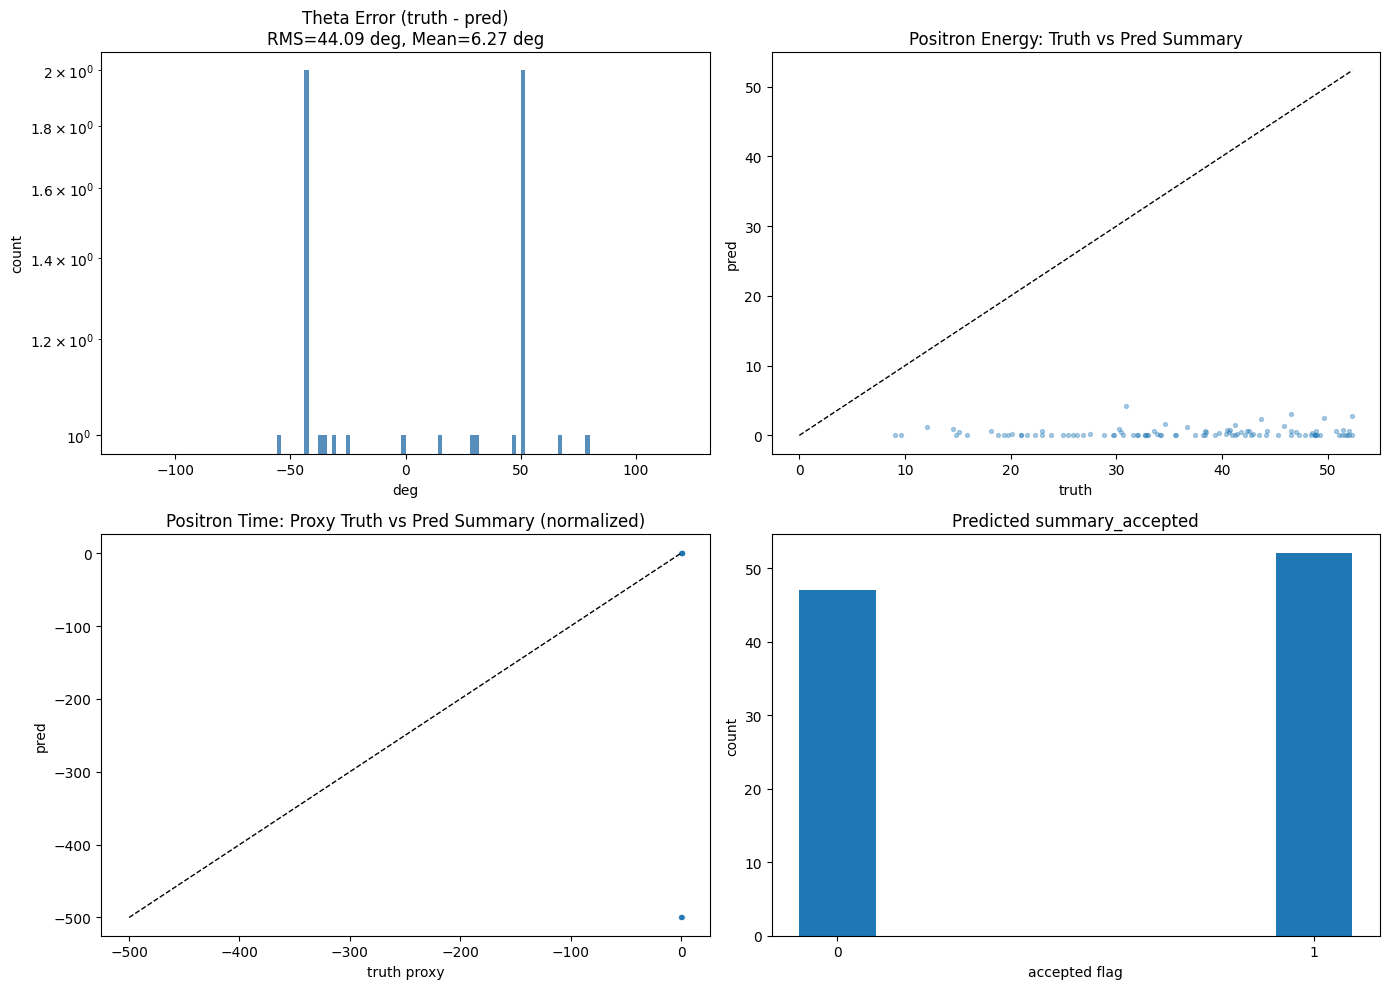

summary_positron_time sentinel fraction: 0.8081


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Theta diff
ax = axes[0, 0]
if theta_diff_deg.size > 0:
    rms = float(np.sqrt(np.mean(theta_diff_deg ** 2)))
    mean = float(np.mean(theta_diff_deg))
    ax.hist(theta_diff_deg, bins=np.arange(-120, 121, 2), color='steelblue', alpha=0.9)
    ax.set_title(f'Theta Error (truth - pred)\nRMS={rms:.2f} deg, Mean={mean:.2f} deg')
    ax.set_xlabel('deg')
    ax.set_ylabel('count')
    ax.set_yscale('log')
else:
    ax.text(0.5, 0.5, 'No theta points', ha='center', va='center')
    ax.set_axis_off()

# 2) Positron energy scatter
ax = axes[0, 1]
if energy_pred.size > 0 and energy_truth.size > 0:
    m = min(energy_pred.size, energy_truth.size)
    x = energy_truth[:m]
    y = energy_pred[:m]
    ax.scatter(x, y, s=8, alpha=0.35)
    lo = float(np.nanmin([x.min(), y.min()]))
    hi = float(np.nanmax([x.max(), y.max()]))
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.set_title('Positron Energy: Truth vs Pred Summary')
    ax.set_xlabel('truth')
    ax.set_ylabel('pred')
else:
    ax.text(0.5, 0.5, 'No energy points', ha='center', va='center')
    ax.set_axis_off()

# 3) Positron time scatter (proxy truth)
ax = axes[1, 0]
if time_pred.size > 0 and time_truth_proxy.size > 0:
    m = min(time_pred.size, time_truth_proxy.size)
    x = time_truth_proxy[:m]
    y = time_pred[:m]
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    if x.size > 0:
        ax.scatter(x, y, s=8, alpha=0.35)
        lo = float(np.nanmin([x.min(), y.min()]))
        hi = float(np.nanmax([x.max(), y.max()]))
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
        ax.set_title('Positron Time: Proxy Truth vs Pred Summary (normalized)')
        ax.set_xlabel('truth proxy')
        ax.set_ylabel('pred')
    else:
        ax.text(0.5, 0.5, 'No finite time points', ha='center', va='center')
        ax.set_axis_off()
else:
    ax.text(0.5, 0.5, 'No time points', ha='center', va='center')
    ax.set_axis_off()

# 4) Acceptance histogram
ax = axes[1, 1]
if accepted_vals.size > 0:
    ax.hist(accepted_vals, bins=[-0.1, 0.1, 0.9, 1.1], rwidth=0.8)
    ax.set_xticks([0.0, 1.0])
    ax.set_title('Predicted summary_accepted')
    ax.set_xlabel('accepted flag')
    ax.set_ylabel('count')
else:
    ax.text(0.5, 0.5, 'No accepted values', ha='center', va='center')
    ax.set_axis_off()

plt.tight_layout()
plt.show()

if time_pred.size > 0:
    sentinel_frac = float(np.mean(time_pred < -499.0))
    print(f'summary_positron_time sentinel fraction: {sentinel_frac:.4f}')
